In [10]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

Matplotlib is building the font cache; this may take a moment.


### Carregar a base de dados

In [2]:
df = pd.read_csv("../assets/ai4i2020.csv")
df.head(10)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,0,0,0,0,0
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,0,0,0,0,0
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,0,0,0,0,0
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,0,0,0,0,0
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,0,0,0,0,0


In [32]:
df['UDI'].nunique()

10000

### Validação de info da base

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

### Estatísticas da base

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


Air temperature [K]
* Apresenta baixa variabilidade. 
* Analisar valores extremos apesar da estabilidade

Process temperature [K]
* Pouca dispersão

Rotational speed [rpm]
* Maior dispersão entre variáveis 
* Procurar outliers 

Torque [Nm]
* Possui grande amplitude de valores

Tool wear [min]
* Apresenta alta variação devido ao desgaste acumulado da ferramenta. 
* Valores elevados

In [8]:
df.head(2)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0


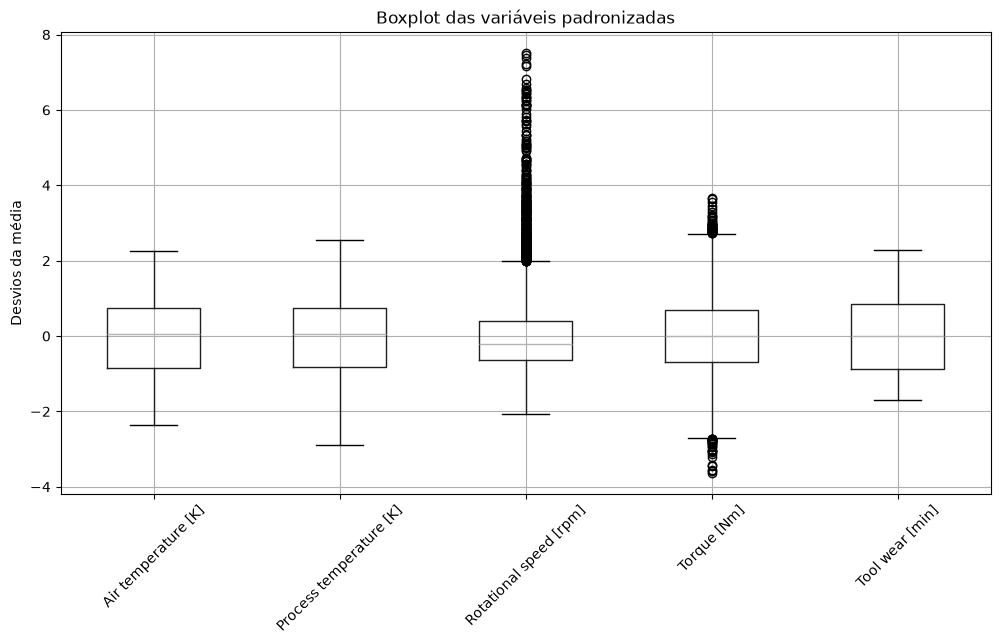

In [13]:
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler

features = [
    'Air temperature [K]',
    'Process temperature [K]', 
    'Rotational speed [rpm]', 
    'Torque [Nm]', 
    'Tool wear [min]'
]


scaler = StandardScaler()

df_scaled = df.copy()

df_scaled[features] = scaler.fit_transform(df[features])


plt.figure(figsize=(12,6))

df_scaled[features].boxplot()

plt.xticks(rotation=45)
plt.title("Boxplot das variáveis padronizadas")

plt.ylabel("Desvios da média")

plt.show()

Torque e Rotational Speed possuem um número grande de outliers

#### Rotational Speed - BoxPlot em falhas

<Figure size 400x400 with 0 Axes>

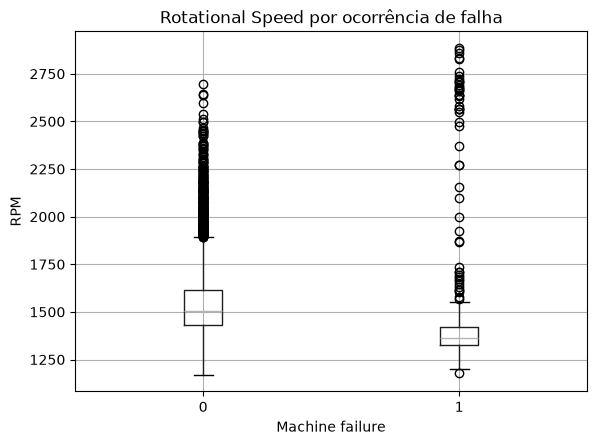

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4,4))
df.boxplot(column='Rotational speed [rpm]', by='Machine failure')
plt.title('Rotational Speed por ocorrência de falha')
plt.suptitle('')
plt.ylabel('RPM')
plt.show()

#### Torque - BoxPlot e análise de falhas

<Figure size 400x400 with 0 Axes>

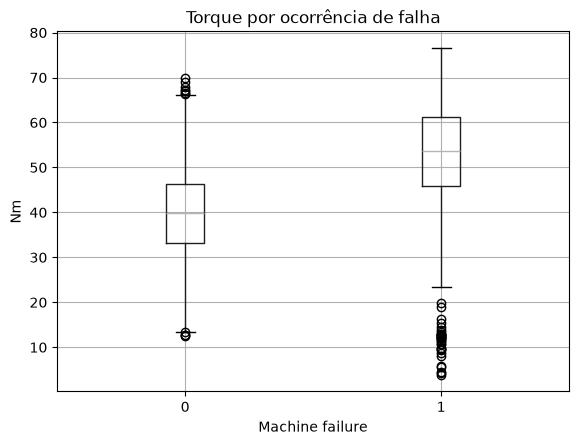

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4,4))
df.boxplot(column='Torque [Nm]', by='Machine failure')
plt.title('Torque por ocorrência de falha')
plt.suptitle('')
plt.ylabel('Nm')
plt.show()

In [20]:
df.groupby("Machine failure")[
    ["Rotational speed [rpm]", "Torque [Nm]"]
].agg(["mean", "median", "std"]).T

Machine failure                          0            1
Rotational speed [rpm] mean    1540.260014  1496.486726
                       median  1507.000000  1365.000000
                       std      167.394734   384.943547
Torque [Nm]            mean      39.629655    50.168142
                       median    39.900000    53.700000
                       std        9.472080    16.374498

### Padronização de Features

In [21]:
from sklearn.preprocessing import StandardScaler

features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

df_scaled = df.copy()

scaler = StandardScaler()

df_scaled[features] = scaler.fit_transform(df_scaled[features])

#### Matriz de Correlação

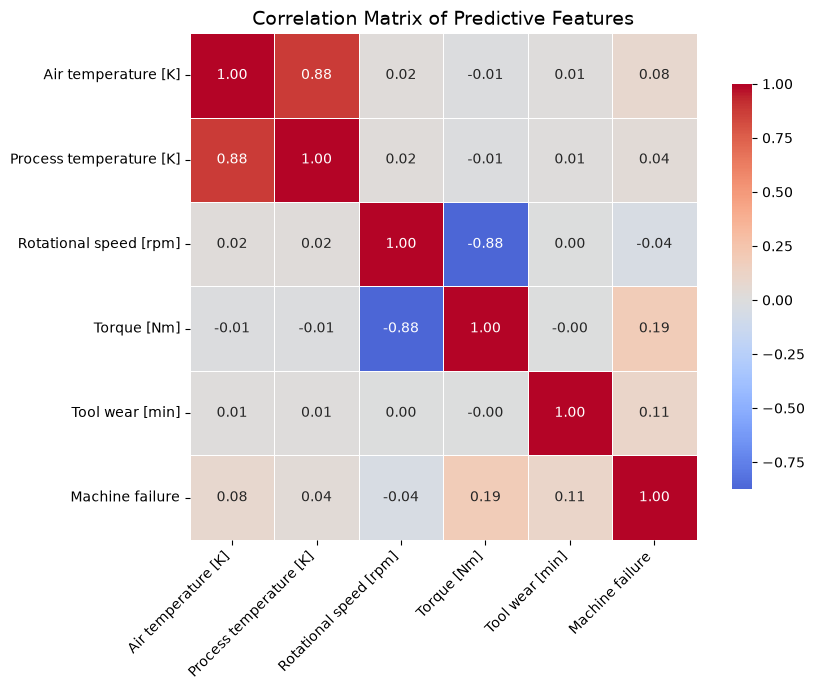

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Removendo variáveis que causam data leakage e identificadores
corr_df = df_scaled.drop(columns=[
    'UDI',
    'TWF',
    'HDF',
    'PWF',
    'OSF',
    'RNF'
])

# Calculando a matriz de correlação
corr = corr_df.corr(numeric_only=True)

# Plot
plt.figure(figsize=(9, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 10}
)

plt.title("Correlation Matrix of Predictive Features", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Rotational speed [rpm]    -0.044188
Process temperature [K]    0.035946
Name: Machine failure, dtype: float64


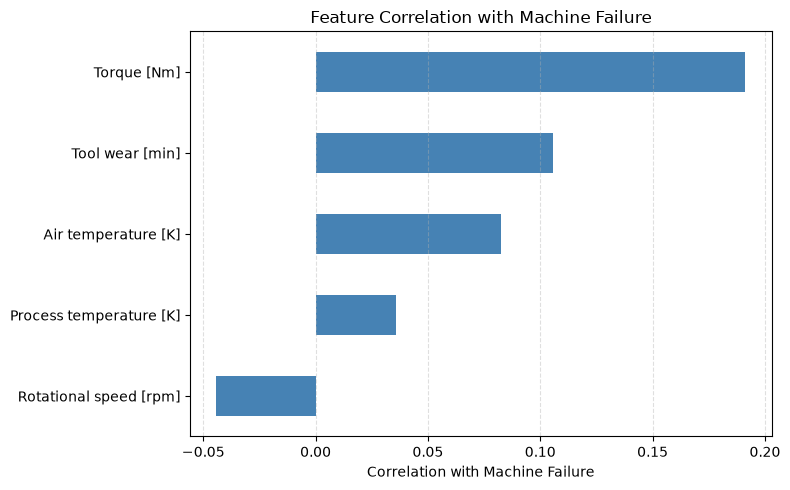

In [25]:
plt.figure(figsize=(8,5))

corr_machine = (
    corr["Machine failure"]
    .drop("Machine failure")
    .sort_values(key=abs, ascending=False)
)

print(corr_machine)

corr_machine.sort_values().plot(
    kind="barh",
    color="steelblue"
)

plt.xlabel("Correlation with Machine Failure")
plt.title("Feature Correlation with Machine Failure")
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

#### Conclusão

* O dataset não possui valores ausentes ou duplicados.

A análise estatística e visual das variáveis evidenciou a presença de outliers, principalmente nas variáveis Rotational Speed [rpm] e Torque [Nm]. Entretanto, esses valores não foram considerados erros, pois representam condições extremas de operação que podem estar diretamente relacionadas à ocorrência de falhas e, portanto, não devem ser removidos sem uma investigação mais aprofundada.

A comparação entre máquinas com e sem falha mostrou que o Torque [Nm] apresenta uma associação mais evidente com a variável alvo (Machine Failure), indicando que máquinas submetidas a maiores níveis de torque possuem maior probabilidade de falhar. A Rotational Speed [rpm] também apresentou diferenças entre as classes, porém com menor capacidade de separação.

A matriz de correlação revelou uma forte correlação positiva entre Air Temperature e Process Temperature (0,88), bem como uma forte correlação negativa entre Rotational Speed e Torque (-0,88), indicando possível multicolinearidade entre essas variáveis. Apesar disso, nenhuma variável foi removida nesta etapa, uma vez que sua relevância será avaliada posteriormente durante o processo de modelagem.

Por fim, as análises realizadas forneceram uma compreensão abrangente do comportamento dos dados, permitindo identificar variáveis potencialmente relevantes para a predição de falhas e estabelecendo uma base sólida para as etapas de análise de confiabilidade e desenvolvimento dos modelos de Machine Learning.